In [1]:
import os
import pandas as pd

genus_name = 'Escherichia'

os.chdir(f'/active-data/analysis_results/chr_pla/genus/figure_data/example_coverage/{genus_name}')
data = pd.read_csv('region_gene_data.tsv', sep='\t', index_col=0)

cog_cols = data.columns[4:]

df_ratio = data.copy()
for letter in cog_cols:
    df_ratio[letter] = df_ratio[letter] / df_ratio['CDSs (with protein)']

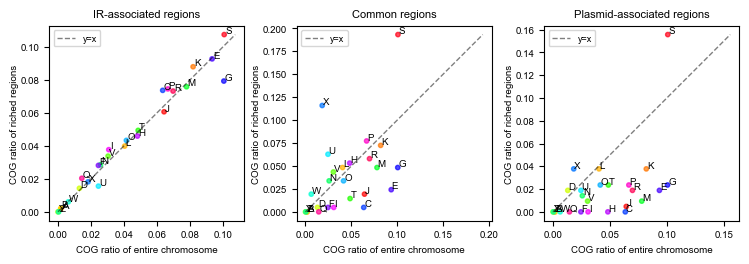

In [2]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
import matplotlib.cm as cm


font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()

plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

italic_font = FontProperties(fname=ifont_path)
normal_font = FontProperties(fname=font_path)
legend_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=8)

def plot_cog_scatter(ax, ref_row, target_row, cog_cols, region_name, genus_name):
    region_names = {'Intermediate replicon': 'IR-associated regions', 'Common region': 'Common regions', 'Typical plasmid': 'Plasmid-associated regions'}
    x = [ref_row[c] for c in cog_cols]
    y = [target_row[c] for c in cog_cols]
    labels = cog_cols
    point_colors = [cog_color_dict[lab] for lab in labels]

    ax.scatter(x, y, s=10, alpha=0.7, c=point_colors)
    ax.set_aspect('equal', adjustable='box')

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    for xi, yi, lab in zip(x, y, labels):
        ax.text(xi+x_max*0.005, yi+y_max*0.005, lab)
        
    lim_max = max(max(x), max(y))
    ax.plot([0, lim_max], [0, lim_max], 'k--', lw=1, alpha=0.5, label='y=x')

    ax.set_xlabel('COG ratio of entire chromosome')
    ax.set_ylabel(f'COG ratio of riched regions', labelpad=1)
    ax.set_title(f'{region_names[region_name]}')
    ax.legend()

n_cog = len(cog_cols)
cog_color_list = []
for i in range(n_cog):
    norm_val = i / (n_cog - 1)
    cog_color_list.append(cm.hsv(norm_val))
cog_color_dict = dict(zip(cog_cols, cog_color_list))

fig = plt.figure(figsize=(7.5, 7.5))

ax1 = fig.add_axes([0.08, 0.74, 0.26, 0.26])
ax2 = fig.add_axes([0.08+0.33, 0.74, 0.26, 0.26])
ax3 = fig.add_axes([0.08+0.33*2, 0.74, 0.26, 0.26])

for region, ax in zip(['Intermediate replicon', 'Common region', 'Typical plasmid'], [ax1, ax2, ax3]):
    ref_row = df_ratio[df_ratio['region_name'] == 'Contig ref'].iloc[0]
    target_row = df_ratio[df_ratio['region_name'] == region].iloc[0]
    plot_cog_scatter(ax, ref_row, target_row, cog_cols, region, genus_name)


base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_enriched_region_comparison.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_enriched_region_comparison.png", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()